## Etapa 1 - Importando Bibliotecas

In [1]:
!pip uninstall -y opencv-python opencv-python-headless opencv-contrib-python opencv-contrib-python-headless
!pip install opencv-python==4.10.0.84

Found existing installation: opencv-python 4.10.0.84
Uninstalling opencv-python-4.10.0.84:
  Successfully uninstalled opencv-python-4.10.0.84
  Using cached opencv_python-4.10.0.84-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (20 kB)
Using cached opencv_python-4.10.0.84-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (62.5 MB)


In [2]:
import cv2
import numpy as np
import pandas as pd
from google.colab.patches import cv2_imshow
import zipfile

In [3]:
%tensorflow_version 2.x

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


In [4]:
import tensorflow
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import img_to_array
tensorflow.__version__

'2.20.0'

## Etapa 2 - Conectando com o Drive e acessando os arquivos

In [5]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [6]:
path = "/content/gdrive/MyDrive/Colab Notebooks/Card 22/aula/Material.zip"
zip_object = zipfile.ZipFile(file=path, mode="r")
zip_object.extractall('./')
zip_object.close

<bound method ZipFile.close of <zipfile.ZipFile filename='/content/gdrive/MyDrive/Colab Notebooks/Card 22/aula/Material.zip' mode='r'>>

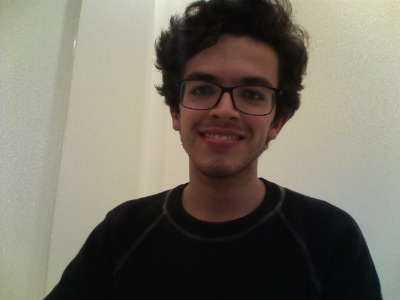

In [7]:
imagem = cv2.imread('Material/testes/teste_gabriel.png') # pegar a imagem usando o OpenCV
cv2_imshow(imagem) # exibi a imagem

In [15]:
imagem.shape

(300, 400, 3)

## Testando o Detector

## Carregamento dos modelos

In [8]:
!pip install tf_keras

In [9]:
from tf_keras.models import load_model
import tensorflow

cascade_faces = "Material/haarcascade_frontalface_default.xml" # arquivo para trabalhar com detecção de faces
caminho_modelo = "Material/modelo_01_expressoes.h5" # modelo pré-treinado
face_detection = cv2.CascadeClassifier(cascade_faces) # carregando o modelo para detecção de faces usando o OpenCV
classificador_emocoes = load_model(caminho_modelo, compile = False) # carregando um modelo salvo do tensorflow
expressoes = ['Raiva', 'Nojo', 'Medo', 'Feliz', 'Triste', 'Surpreso', 'Neutro'] # 7 categorias

## Detecção de faces

In [11]:
original = imagem.copy() # copiar a imagem
faces = face_detection.detectMultiScale(original, scaleFactor=1.1,
                                        minNeighbors=3, minSize=(20, 20)) # numero min de vizinhos de detecção e tamano min da faces

In [14]:
faces # posição x, y (pixel)da face

array([[162,  40, 128, 128]], dtype=int32)

In [16]:
len(faces) # quantos registros tem

1

In [17]:
faces.shape # visualizar o formato

(1, 4)

## Extração do ROI (Region of interest)

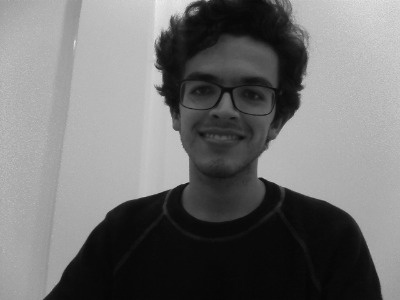

In [18]:
cinza = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY) # converter para escala de cinza
cv2_imshow(cinza) # exibir

In [19]:
cinza.shape # apenas um canal

(300, 400)

In [20]:
roi = cinza[40:40 + 128, 162:162 + 128] # extraindo da posição 40 a 40 somando com 128 para descer a face, deoius no 162 a 162 soma 128 para ir para direita da face

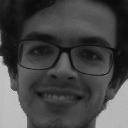

In [22]:
cv2_imshow(roi) # exibir regiao de interesse

In [24]:
roi.shape # dimensao da imagem acima

(128, 128)

array([[ 39,  37,  28, ...,  25,  29,  34],
       [ 34,  32,  25, ...,  24,  24,  29],
       [ 31,  33,  30, ...,  23,  22,  26],
       ...,
       [184, 185, 186, ..., 180, 181, 181],
       [184, 185, 186, ..., 179, 181, 180],
       [184, 185, 187, ..., 180, 181, 180]], dtype=uint8)
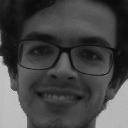

In [25]:
roi # matriz com os valores dos pixeis

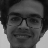

In [26]:
roi = cv2.resize(roi, (48,48)) # redimensiona
cv2_imshow(roi) # exibir

In [27]:
roi.dtype # tipo dos dados

dtype('uint8')

In [29]:
roi = roi.astype('float') # converter para float
roi.dtype # verificar

dtype('float64')

In [30]:
roi

array([[ 33.,  29.,  38., ...,  16.,  22.,  25.],
       [ 32.,  37.,  37., ...,  16.,  20.,  25.],
       [ 32.,  36.,  31., ...,  17.,  21.,  25.],
       ...,
       [186., 189., 189., ..., 181., 181., 180.],
       [185., 188., 189., ..., 180., 181., 180.],
       [185., 188., 188., ..., 179., 180., 181.]])

In [31]:
roi = roi / 255 # converter para escala 0 e 1

In [32]:
roi

array([[0.12941176, 0.11372549, 0.14901961, ..., 0.0627451 , 0.08627451,
        0.09803922],
       [0.1254902 , 0.14509804, 0.14509804, ..., 0.0627451 , 0.07843137,
        0.09803922],
       [0.1254902 , 0.14117647, 0.12156863, ..., 0.06666667, 0.08235294,
        0.09803922],
       ...,
       [0.72941176, 0.74117647, 0.74117647, ..., 0.70980392, 0.70980392,
        0.70588235],
       [0.7254902 , 0.7372549 , 0.74117647, ..., 0.70588235, 0.70980392,
        0.70588235],
       [0.7254902 , 0.7372549 , 0.7372549 , ..., 0.70196078, 0.70588235,
        0.70980392]])

In [33]:
roi = img_to_array(roi) # conveter para array

In [34]:
roi

array([[[0.12941177],
        [0.11372549],
        [0.14901961],
        ...,
        [0.0627451 ],
        [0.08627451],
        [0.09803922]],

       [[0.1254902 ],
        [0.14509805],
        [0.14509805],
        ...,
        [0.0627451 ],
        [0.07843138],
        [0.09803922]],

       [[0.1254902 ],
        [0.14117648],
        [0.12156863],
        ...,
        [0.06666667],
        [0.08235294],
        [0.09803922]],

       ...,

       [[0.7294118 ],
        [0.7411765 ],
        [0.7411765 ],
        ...,
        [0.70980394],
        [0.70980394],
        [0.7058824 ]],

       [[0.7254902 ],
        [0.7372549 ],
        [0.7411765 ],
        ...,
        [0.7058824 ],
        [0.70980394],
        [0.7058824 ]],

       [[0.7254902 ],
        [0.7372549 ],
        [0.7372549 ],
        ...,
        [0.7019608 ],
        [0.7058824 ],
        [0.70980394]]], dtype=float32)

In [35]:
roi.shape

(48, 48, 1)

In [36]:
roi = np.expand_dims(roi, axis=0) # expandir a dimensao

In [37]:
roi.shape

(1, 48, 48, 1)

## Previsões

In [45]:
preds = classificador_emocoes.predict(roi)[0] # previsao
#ao adicionar o 0 ele indica que está puxando a primeira posição

1/1 [==============================] - 0s 76ms/step


In [40]:
preds

array([1.6802096e-05, 5.7679665e-09, 1.1206557e-05, 9.9066460e-01,
       1.8033754e-05, 1.8518243e-05, 9.2708124e-03], dtype=float32)

In [41]:
len(preds) # verficar se tem 7 classes

7

In [42]:
emotion_probability = np.max(preds) # encontra o valor maior das 7 classes(feliz)
emotion_probability

np.float32(0.9906646)

In [43]:
preds.argmax() # encontra a posicao que esta o maior valor

np.int64(3)

In [44]:
label = expressoes[preds.argmax()]
label # visualizar a resposta feliz da lista

'Feliz'

# Resultados

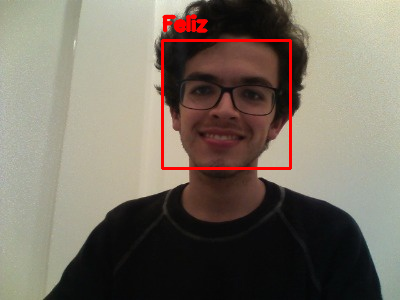

In [60]:
cv2.putText(original, label, (162, 40 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.65,
            (0,0,255), 2, cv2.LINE_AA) # Configurando o texto que aparecerá na imagem
cv2.rectangle(original, (162, 40), (162 + 128, 40 + 128), (0,0, 255), 2) # criando o retangulo
cv2_imshow(original) # exibir

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
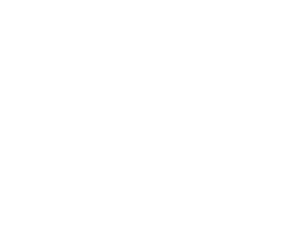

In [49]:
probabilidades = np.ones((250, 300, 3), dtype="uint8") * 255 # desenho das barrinhas de progresso
probabilidades

In [50]:
probabilidades.shape

(250, 300, 3)

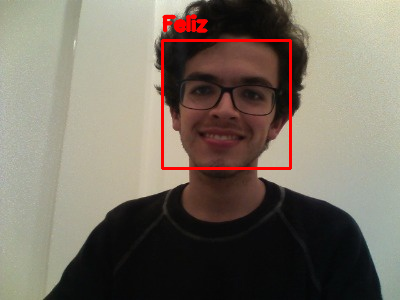

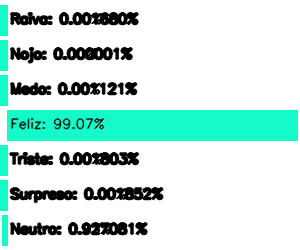

In [61]:
cv2_imshow(original) # mostra a imagem original
if len(faces) == 1: # se tiver apenas uma face
  for (i, (emotion, prob)) in enumerate(zip(expressoes, preds)): # probabilidades de cada uma das emocoes
     # print(i, emotion, prob)
     text = "{}: {:.2f}%".format(emotion, prob * 100) # criando texto
     w = int(prob * 300) # largura da barra
     cv2.rectangle(probabilidades, (7, (i * 35) + 5), (w, (i * 35) + 35), (200, 250, 20), -1) # é definido o retangulo
     cv2.putText(probabilidades, text, (10, (i * 35) + 23), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 0, 0), 1, cv2.LINE_AA) # colocando o texto no retangulo

cv2_imshow(probabilidades)